In [50]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Levins Model


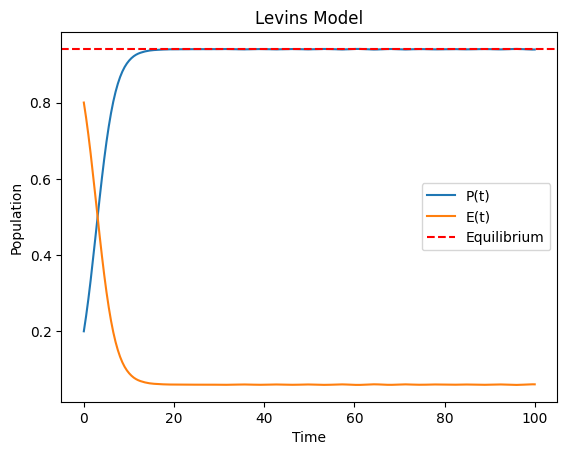

In [51]:
def LevinsModel_deterministic(t, y):
    # Parameters
    settlement_c = 0.5
    extintion_e = 0.03

    # Variables
    P = y[0]
    
    # Equations
    dPdt = settlement_c * P * (1 - P) - extintion_e * P
    return [dPdt]

# Initial condition
y0 = [0.2]  
t_span = (0, 100)
t_eval = np.linspace(*t_span, 200)

# Solve the differential equation
sol = solve_ivp(LevinsModel_deterministic, t_span, y0, t_eval=t_eval)
E = 1 - sol.y[0]
# Plot the solution
plt.plot(sol.t, sol.y[0], label='P(t)')

plt.plot(sol.t, E, label='E(t)')
# plot una retta orizzontale in y = 1 - e/c  (l'equilibrio)
plt.axhline(y=1-0.03/0.5, color='r', linestyle='--', label='Equilibrium')
plt.title('Levins Model')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()


In [52]:
def LevinsMap(e, c, P):
    return c * P * (1 - P) - e * P

def ComputeLogisticModel(x0, e, c, iterations):
    x = x0
    y = [x]
    for i in range(iterations):
        new_x = x + LevinsMap(e, c, x)
        x = new_x
        y.append(x)
    return y

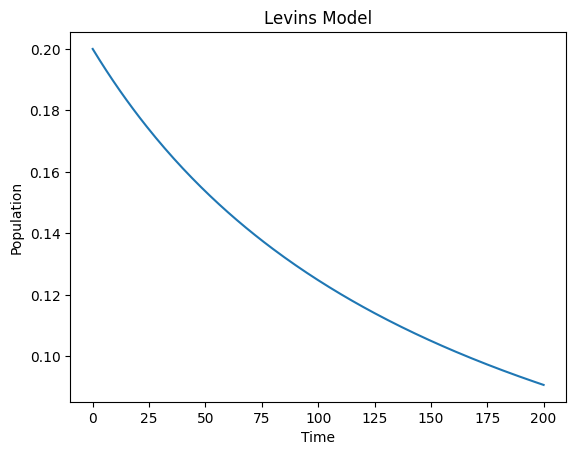

In [66]:
iterations = 200
x0 = 0.2
e = 0.03
c = 0.03
y = ComputeLogisticModel(x0, e, c, iterations)
plt.plot(y)
plt.title('Levins Model')
plt.xlabel('Time')
plt.ylabel('Population')
plt.show()


In [105]:
def plot_derivative_sign(c, e):

    # Caso 1: c > e (equilibrio positivo)
    if c > e:
        # Punto di equilibrio
        P_star = 1 - e / c  # Equilibrio stabile se c > e

        # Definiamo l'intervallo di P
        P_vals = np.linspace(0, 1, 100)
        dPdt_vals = c * P_vals * (1 - P_vals) - e * P_vals  # Equazione di Levins

        # Creazione del grafico
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(P_vals, dPdt_vals, label=r'$\frac{dP}{dt}$', color='black')
        ax.axhline(0, color='gray', linestyle='--')  # Linea orizzontale per dP/dt = 0
        ax.axvline(P_star, color='red', linestyle=':', label=r'$P^* = 1 - \frac{e}{c}$')  # Punto di equilibrio

        # Aggiunta delle frecce per la direzione del cambiamento
        for P in np.linspace(0.05, 0.95, 8):  # Posizioni delle frecce
            dPdt = c * P * (1 - P) - e * P
            if dPdt > 0:
                ax.annotate("", xy=(P + 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
            else:
                ax.annotate("", xy=(P - 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))

        # Etichette e legenda
        ax.set_xlim(0, 1)  # Solo valori validi di P
        ax.set_xlabel("Frazione di habitat occupati (P)")
        ax.set_ylabel(r'$\frac{dP}{dt}$')
        ax.legend()
        ax.set_title("Dinamica del modello con segno della derivata (c > e)")
        plt.grid()
        plt.show()

    # Caso 2: c <= e (estinzione della popolazione)
    else:
        P_vals = np.linspace(0, 1, 100)
        dPdt_vals = c * P_vals * (1 - P_vals) - e * P_vals  # Equazione di Levins

        # Creazione del grafico
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(P_vals, dPdt_vals, label=r'$\frac{dP}{dt}$', color='black')
        ax.axhline(0, color='gray', linestyle='--')  # Linea orizzontale per dP/dt = 0
        
        # Aggiunta delle frecce (solo se rimangono nel dominio valido)
        for P in np.linspace(0.05, 1, 8):  # Posizioni delle frecce
            dPdt = c * P * (1 - P) - e * P
            if dPdt < 0 and P - 0.05 >= 0:  # Assicuriamoci che P-0.05 non sia negativo
                ax.annotate("", xy=(P - 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
        
        # Etichette e legenda
        ax.set_xlim(0, 1)  # Solo valori validi di P
        ax.set_xlabel("Frazione di habitat occupati (P)")
        ax.set_ylabel(r'$\frac{dP}{dt}$')
        ax.legend()
        ax.set_title("Dinamica del modello con segno della derivata (c ≤ e)")
        plt.grid()
        plt.show()

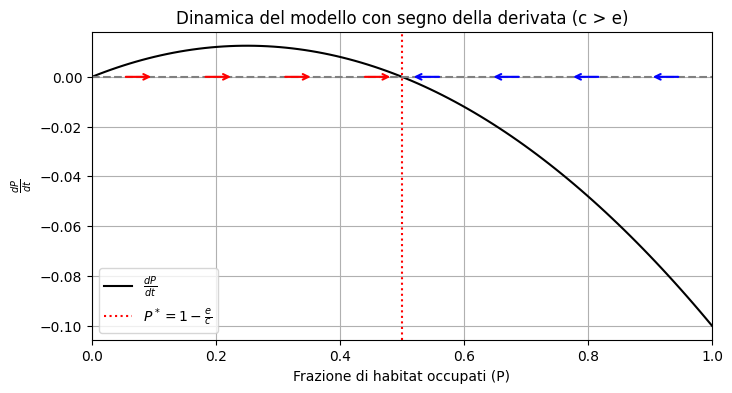

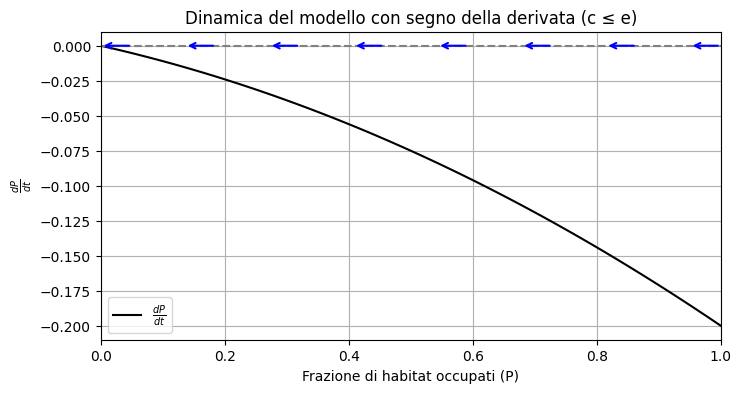

In [106]:
plot_derivative_sign(0.2, 0.1)
plot_derivative_sign(0.1, 0.2)

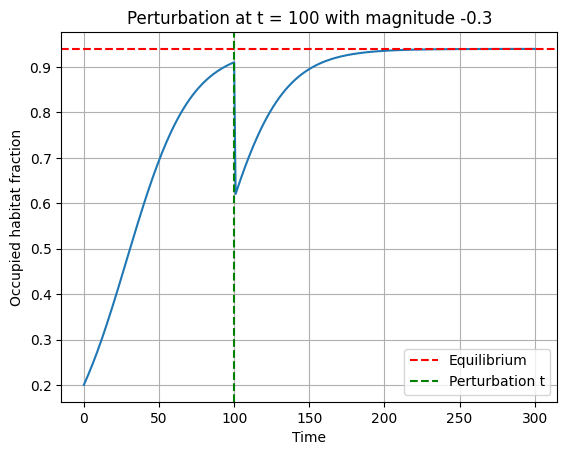

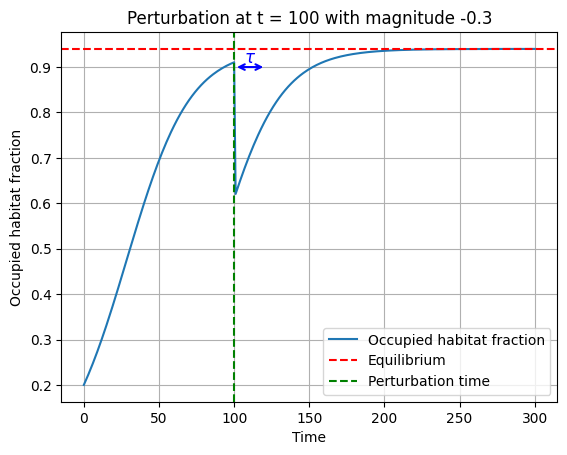

In [144]:
def ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude):
    x = x0
    y = [x]
    for i in range(iterations):
        if i == perturbation_t:
            x = x + p_magnitude
        new_x = x + LevinsMap(e, c, x)
        x = new_x
        y.append(x)
    return y

iterations = 300
x0 = 0.2
e = 0.003
c = 0.05
perturbation_t = 100
p_magnitude = -0.3

y = ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude)

tempo_caratteristico = 1 / (c - e)
t_tau = perturbation_t + tempo_caratteristico

plt.plot(y)
plt.title(f'Perturbation at t = {perturbation_t} with magnitude {p_magnitude}')
plt.axhline(1 - e / c, 0, iterations, color='r', linestyle='--', label='Equilibrium')
plt.axvline(perturbation_t, color='g', linestyle='--', label='Perturbation t')
plt.xlabel('Time')
plt.ylabel('Occupied habitat fraction')
plt.legend()
plt.grid()
plt.show()


plt.plot(y, label='Occupied habitat fraction')
plt.title(f'Perturbation at t = {perturbation_t} with magnitude {p_magnitude}')

# Linea tratteggiata per l'equilibrio
plt.axhline(1 - e / c, color='r', linestyle='--', label='Equilibrium')

# Linea verticale per la perturbazione
plt.axvline(perturbation_t, color='g', linestyle='--', label='Perturbation time')

# Freccia per il tempo caratteristico
plt.annotate('', xy=(perturbation_t, 0.9), xytext=(t_tau, 0.9),
             arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
plt.text((perturbation_t + t_tau) / 2, 0.91, r'$\tau$', color='blue', fontsize=12, ha='center')

# Etichette e legenda
plt.xlabel('Time')
plt.ylabel('Occupied habitat fraction')
plt.legend()
plt.grid()
plt.show()


In [137]:
tempo_caratteristico

21.27659574468085

## Verifichiamo che 0 sia un punto di equilibrio instabile con (e < c)

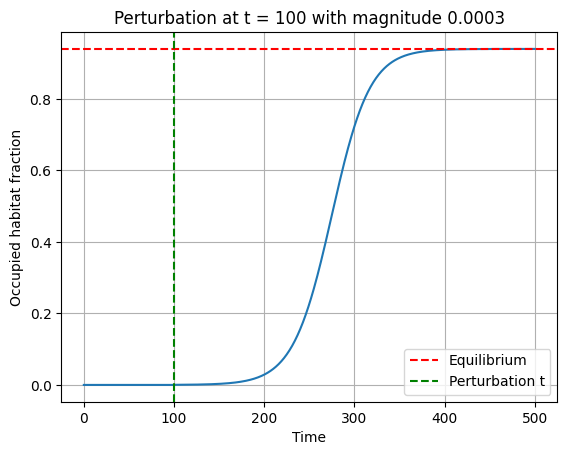

In [142]:
iterations = 500
x0 = 0
e = 0.003
c = 0.05
perturbation_t = 100
p_magnitude = 0.0003

y = ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude)

tempo_caratteristico = 1 / (c - e)
t_tau = perturbation_t + tempo_caratteristico

plt.plot(y)
plt.title(f'Perturbation at t = {perturbation_t} with magnitude {p_magnitude}')
plt.axhline(1 - e / c, 0, iterations, color='r', linestyle='--', label='Equilibrium')
plt.axvline(perturbation_t, color='g', linestyle='--', label='Perturbation t')
plt.xlabel('Time')
plt.ylabel('Occupied habitat fraction')
plt.legend()
plt.grid()
plt.show()

----

# 3-state Metapopulation model

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_18836\3826107497.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


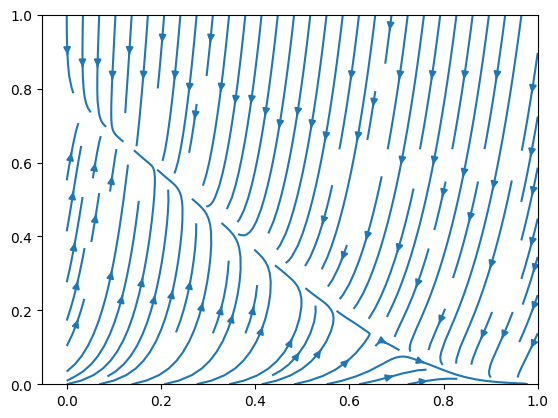

In [147]:
x = np.linspace(0, 1, 20)
y = np.linspace(0, 1, 20)
X,Y = np.meshgrid(x,y)

el = 0.5
es = 0.08
r = 0.02
c = 0.2
m = 2.2

Xdot = es * (1-Y-X) - c * X * Y
Ydot = (r + m*Y) * (1 - Y- X) - el*Y
fig, ax = plt.subplots()
ax.streamplot(X,Y,Xdot,Ydot)
fig.show()